# [LAB-06] 4. Histogram

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *
import seaborn as sb
import numpy as np

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data('employee_data_40')
origin.head()

📚 어느 기업의 직원 40명을 대상으로 성별과 결혼상태, 나이, 최종학력, 월수입을 조사한 가상의 데이터(인덱스, 메타데이터 없음)


,성별,결혼상태,나이,최종학력,월수입
0,남자,기혼,21,대학교,60
1,남자,기혼,22,대학원,100
2,남자,기혼,33,대학교,200
3,여자,미혼,33,대학교,120
4,남자,미혼,28,대학교,70


## #02. Histogram 시각화 하기

### 기본 사용 방법

- `x`축에 연속형 데이터를 지정, `y`축은 데이터의 수로 자동 설정됨
  - 패턴1(자동인식 패턴)의 경우 `x`축으로 지정됨
  - 패턴2(개별 데이터 직접 지정)의 경우 `x`파라미터만 설정
  - 패턴3(DataFrame + 컬럼명)의 경우 `data`와 `x`파라미터만 설정

### 1. 기본 사용 방법

- 구간이 자동으로 계산됨
  - x축 좌표가 임의로 설정되기 때문에 구간을 파악하기 어렵다.

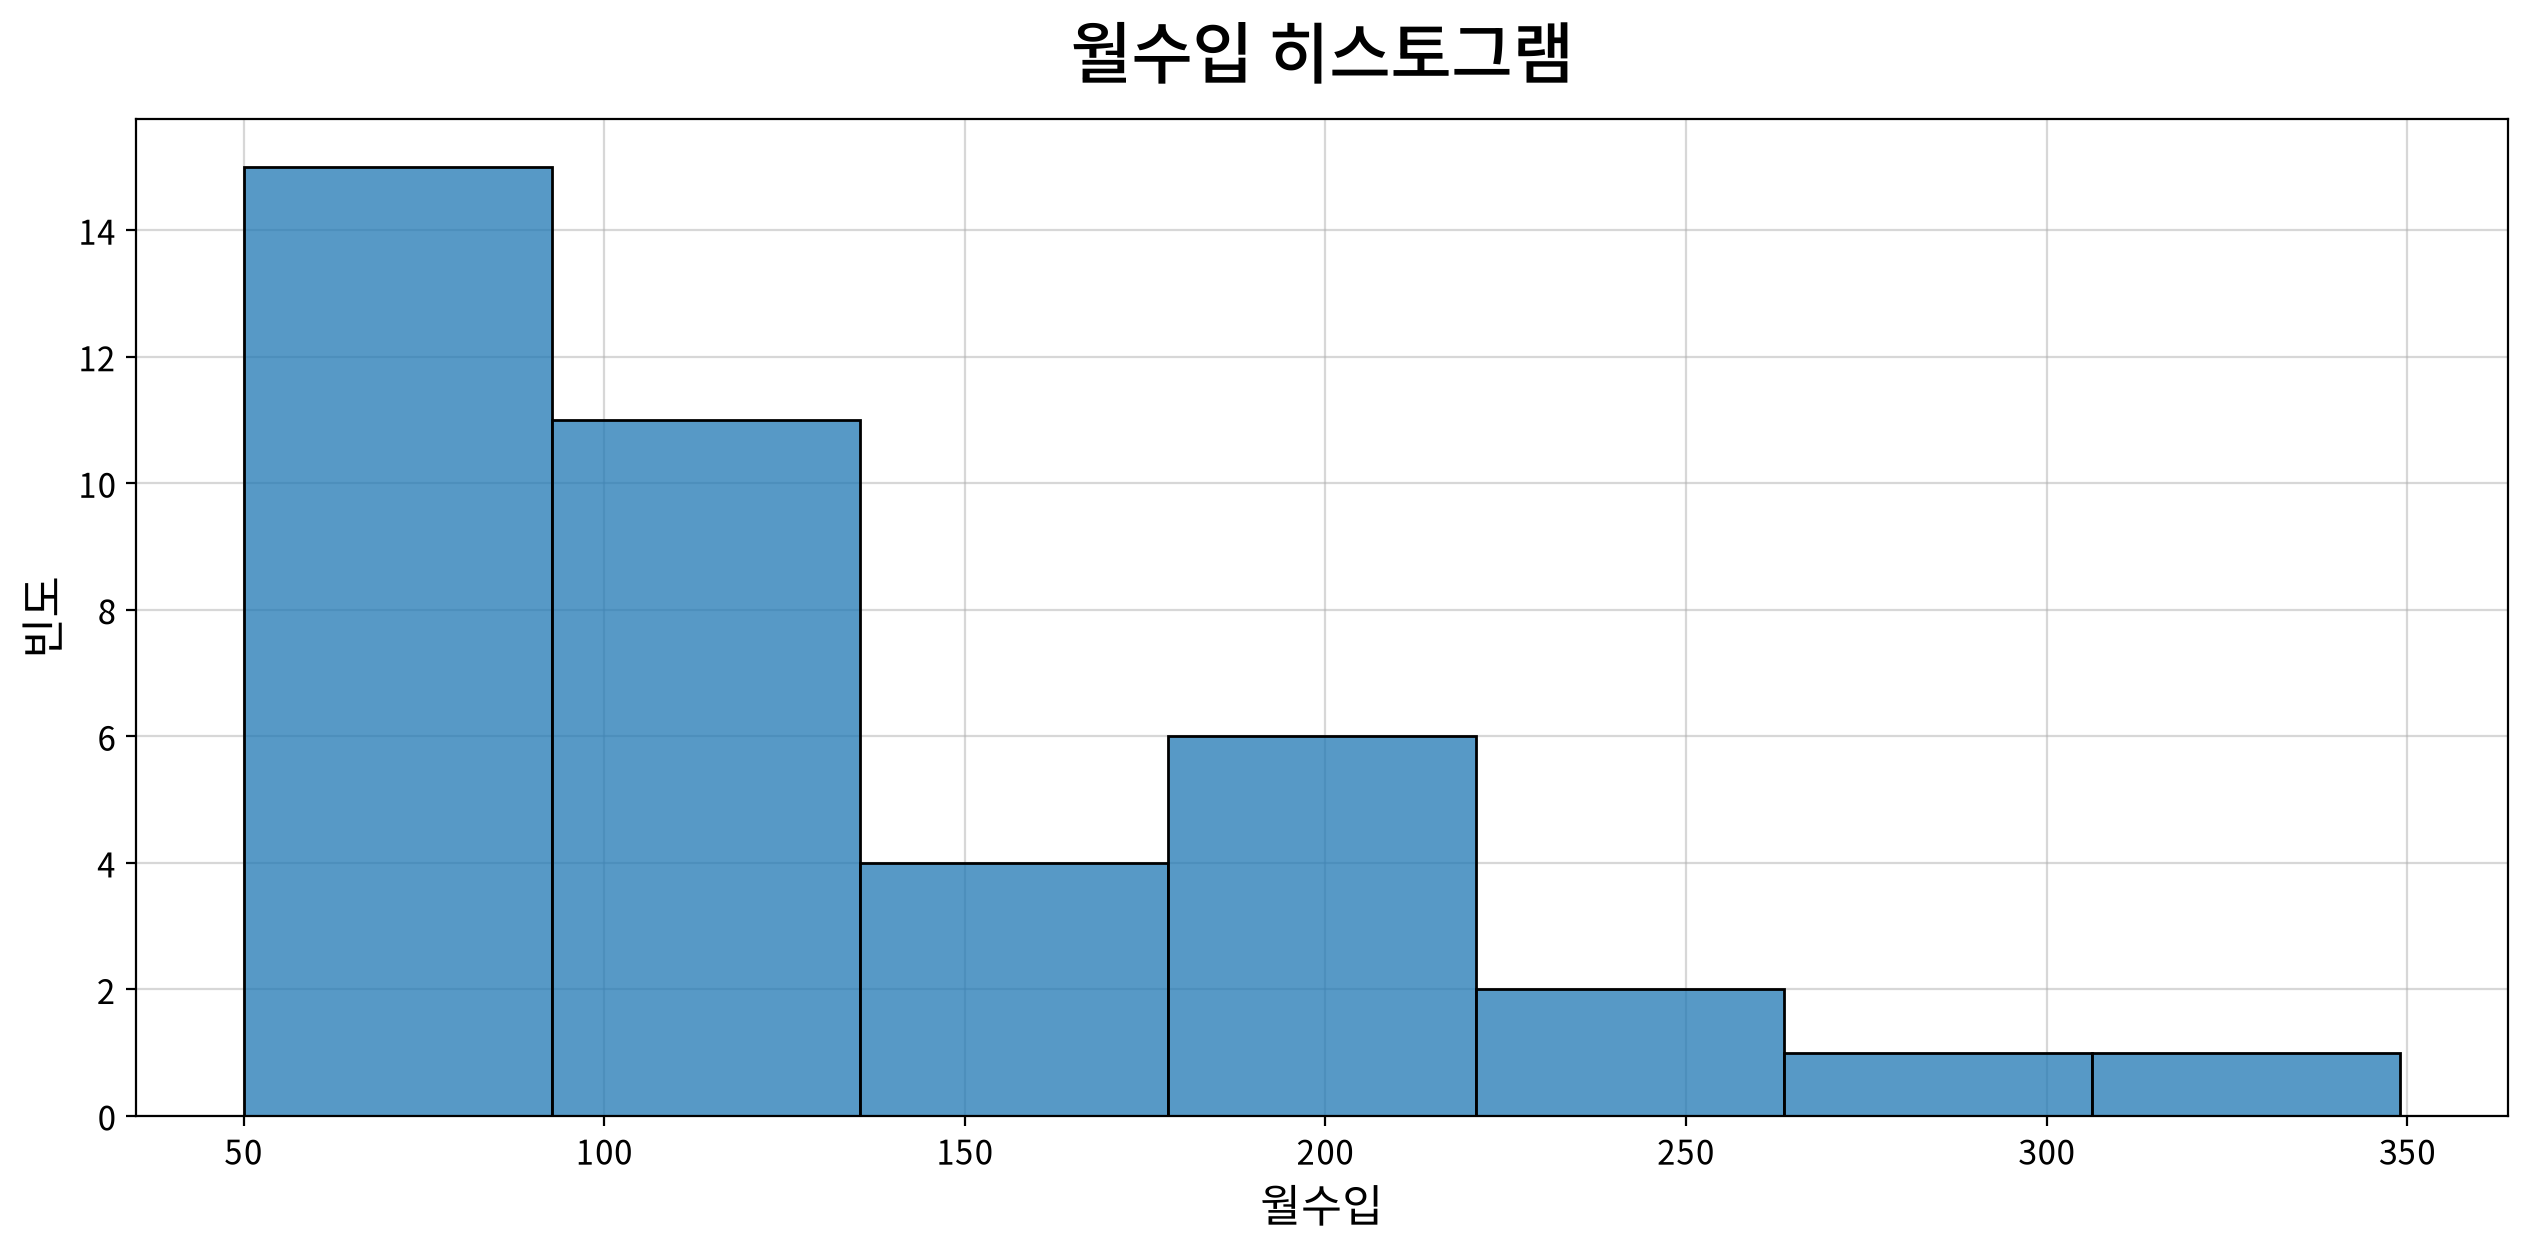

In [3]:
fig, ax = my_plot.init(title='월수입 히스토그램', 
                       xlabel='월수입', ylabel='빈도')

# 패턴1 - 자동인식 패턴
#sb.histplot(data=origin['월수입'])
# 패턴2 - 개별 데이터 직접 지정 패턴
#sb.histplot(x=origin['월수입'])
# 패턴3 - DataFrame + 컬럼명 패턴
sb.histplot(data=origin, x='월수입')

my_plot.show()

## #03. 히스토그램의 구간 설정

### 1. NumPy를 통해 정확한 구간경계 얻기

- `np.histogram()` 함수에 데이터와 구간수(bins)를 지정한다.
- `np.histogram()` 함수의 bins 파라미터에 리스트를 전달하면 히스토그램의 구간을 bins에 지정한 리스트로 설정할 수 있다.
  - 분석가의 주관에 따라 직접 정의한 리스트를 지정하는 것도 가능함
  - 예) [0, 100, 200, 300, 400, 500]

In [4]:
hist, bins = np.histogram(origin['월수입'], bins=5)
# 소수점 1째자리까지 남기고 반올림
bins = np.round(bins, 1)
print("값:", hist)
print("구간:", bins)

값: [20  9  7  2  2]
구간: [ 50.  109.8 169.6 229.4 289.2 349. ]


### 2. NumPy를 통해 구한 구간경계를 히스토그램에 적용

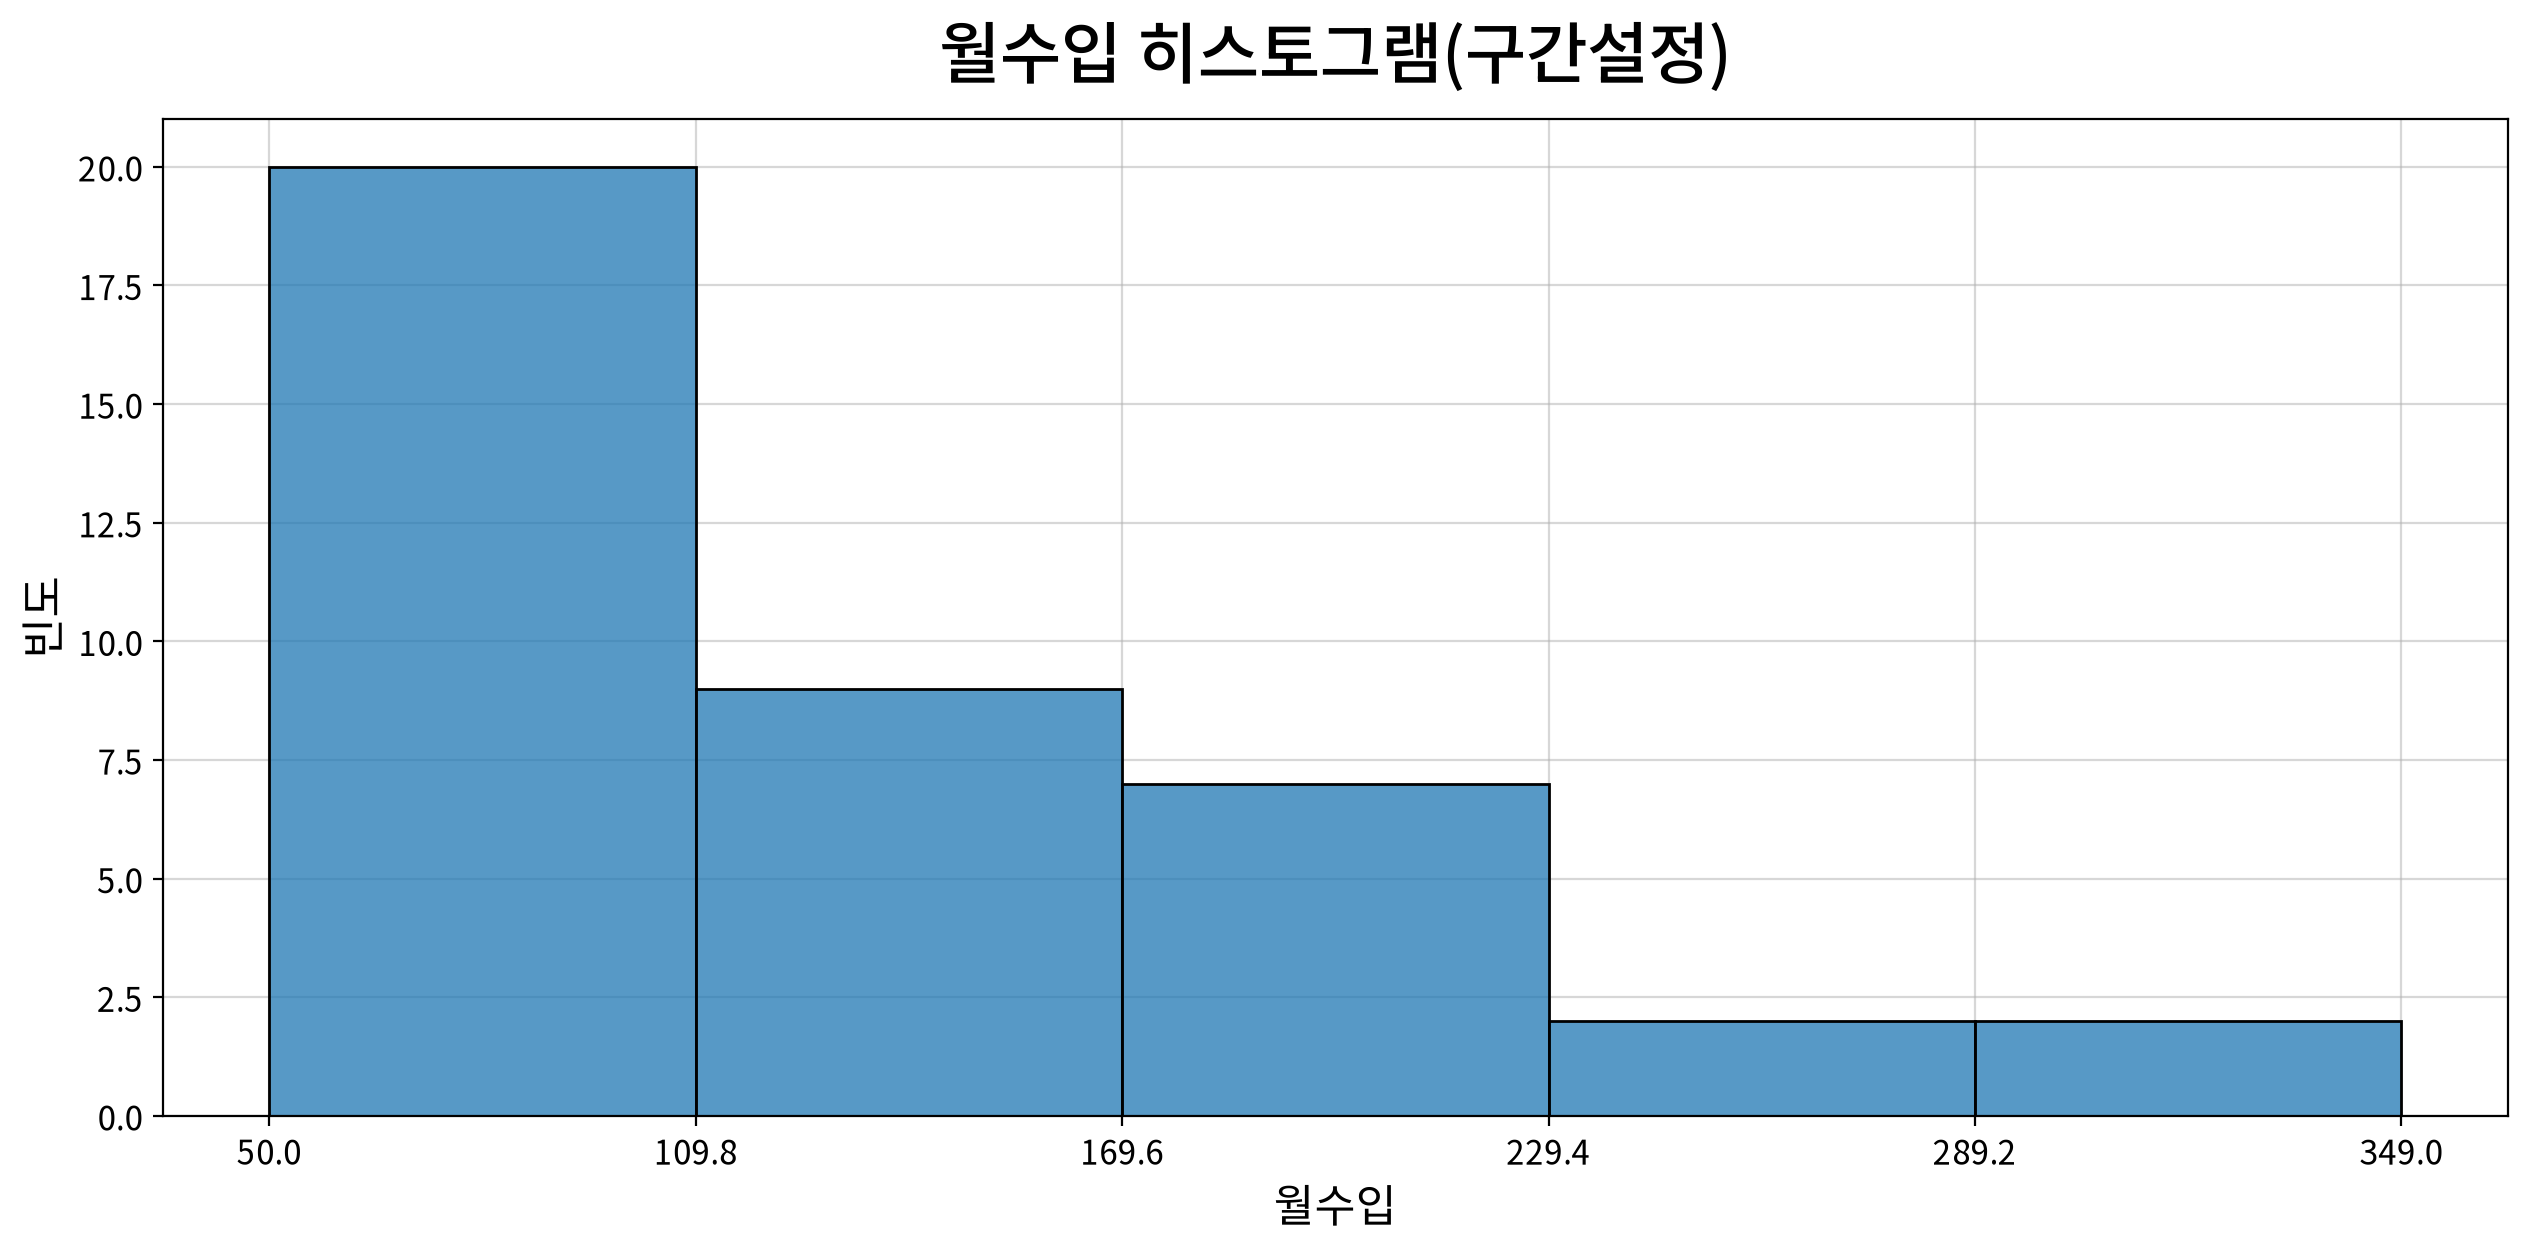

In [5]:
fig, ax = my_plot.init(title='월수입 히스토그램(구간설정)', 
                       xlabel='월수입', ylabel='빈도')

# 구간을 설정한 히스토그램
# -> bins는 이전 코드 블록에서 생성한 정보
sb.histplot(data=origin, x='월수입', bins=bins)

# x축 좌표에 구간값 표시하기
ax.set_xticks(bins, bins)

my_plot.show()

## #04. 히스토그램의 옵션 설정

### 1. 커널밀도와 함께 표시하기

- `kde=True` 파라미터를 추가한다.

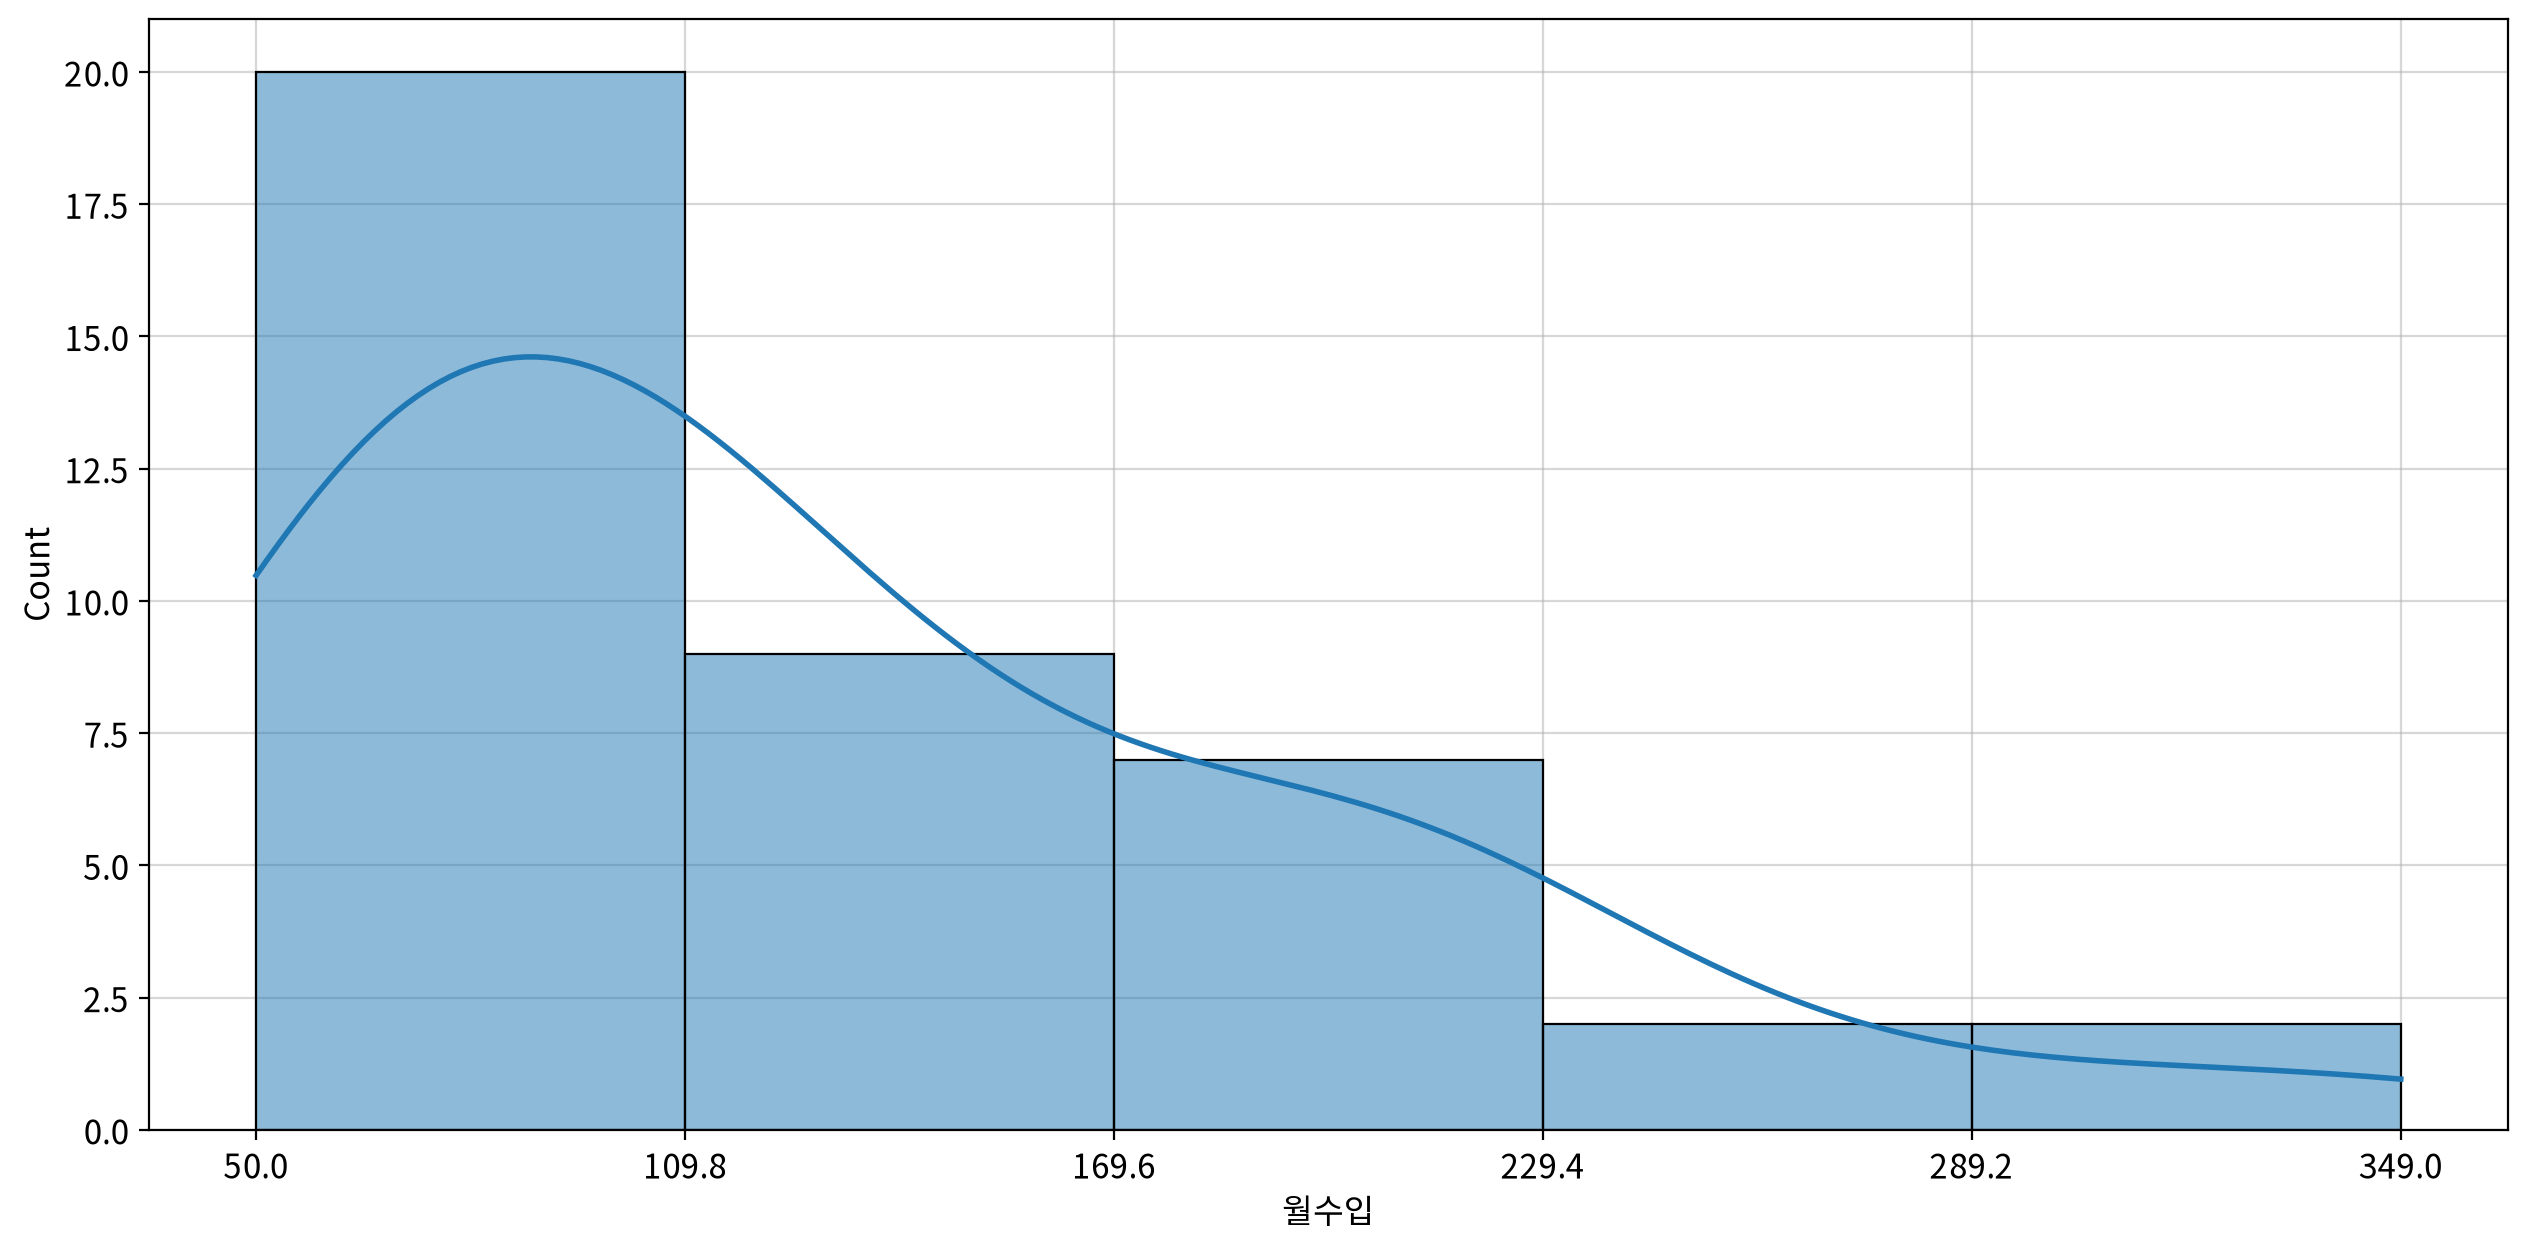

In [6]:
# 그래프 초기화
fig, ax = my_plot.init()

# 구간을 설정한 히스토그램 -> bins는 이전 코드 블록에서 생성한 정보
sb.histplot(data=origin, x='월수입', bins=bins, kde=True, linewidth=0.8)

# x축 좌표에 구간값 표시하기
ax.set_xticks(bins, bins)

# 출력
my_plot.show()

### 2. 범주 구분, 선 색상/굵기 설정하기

- 성별에 따른 월 수입 히스토그램

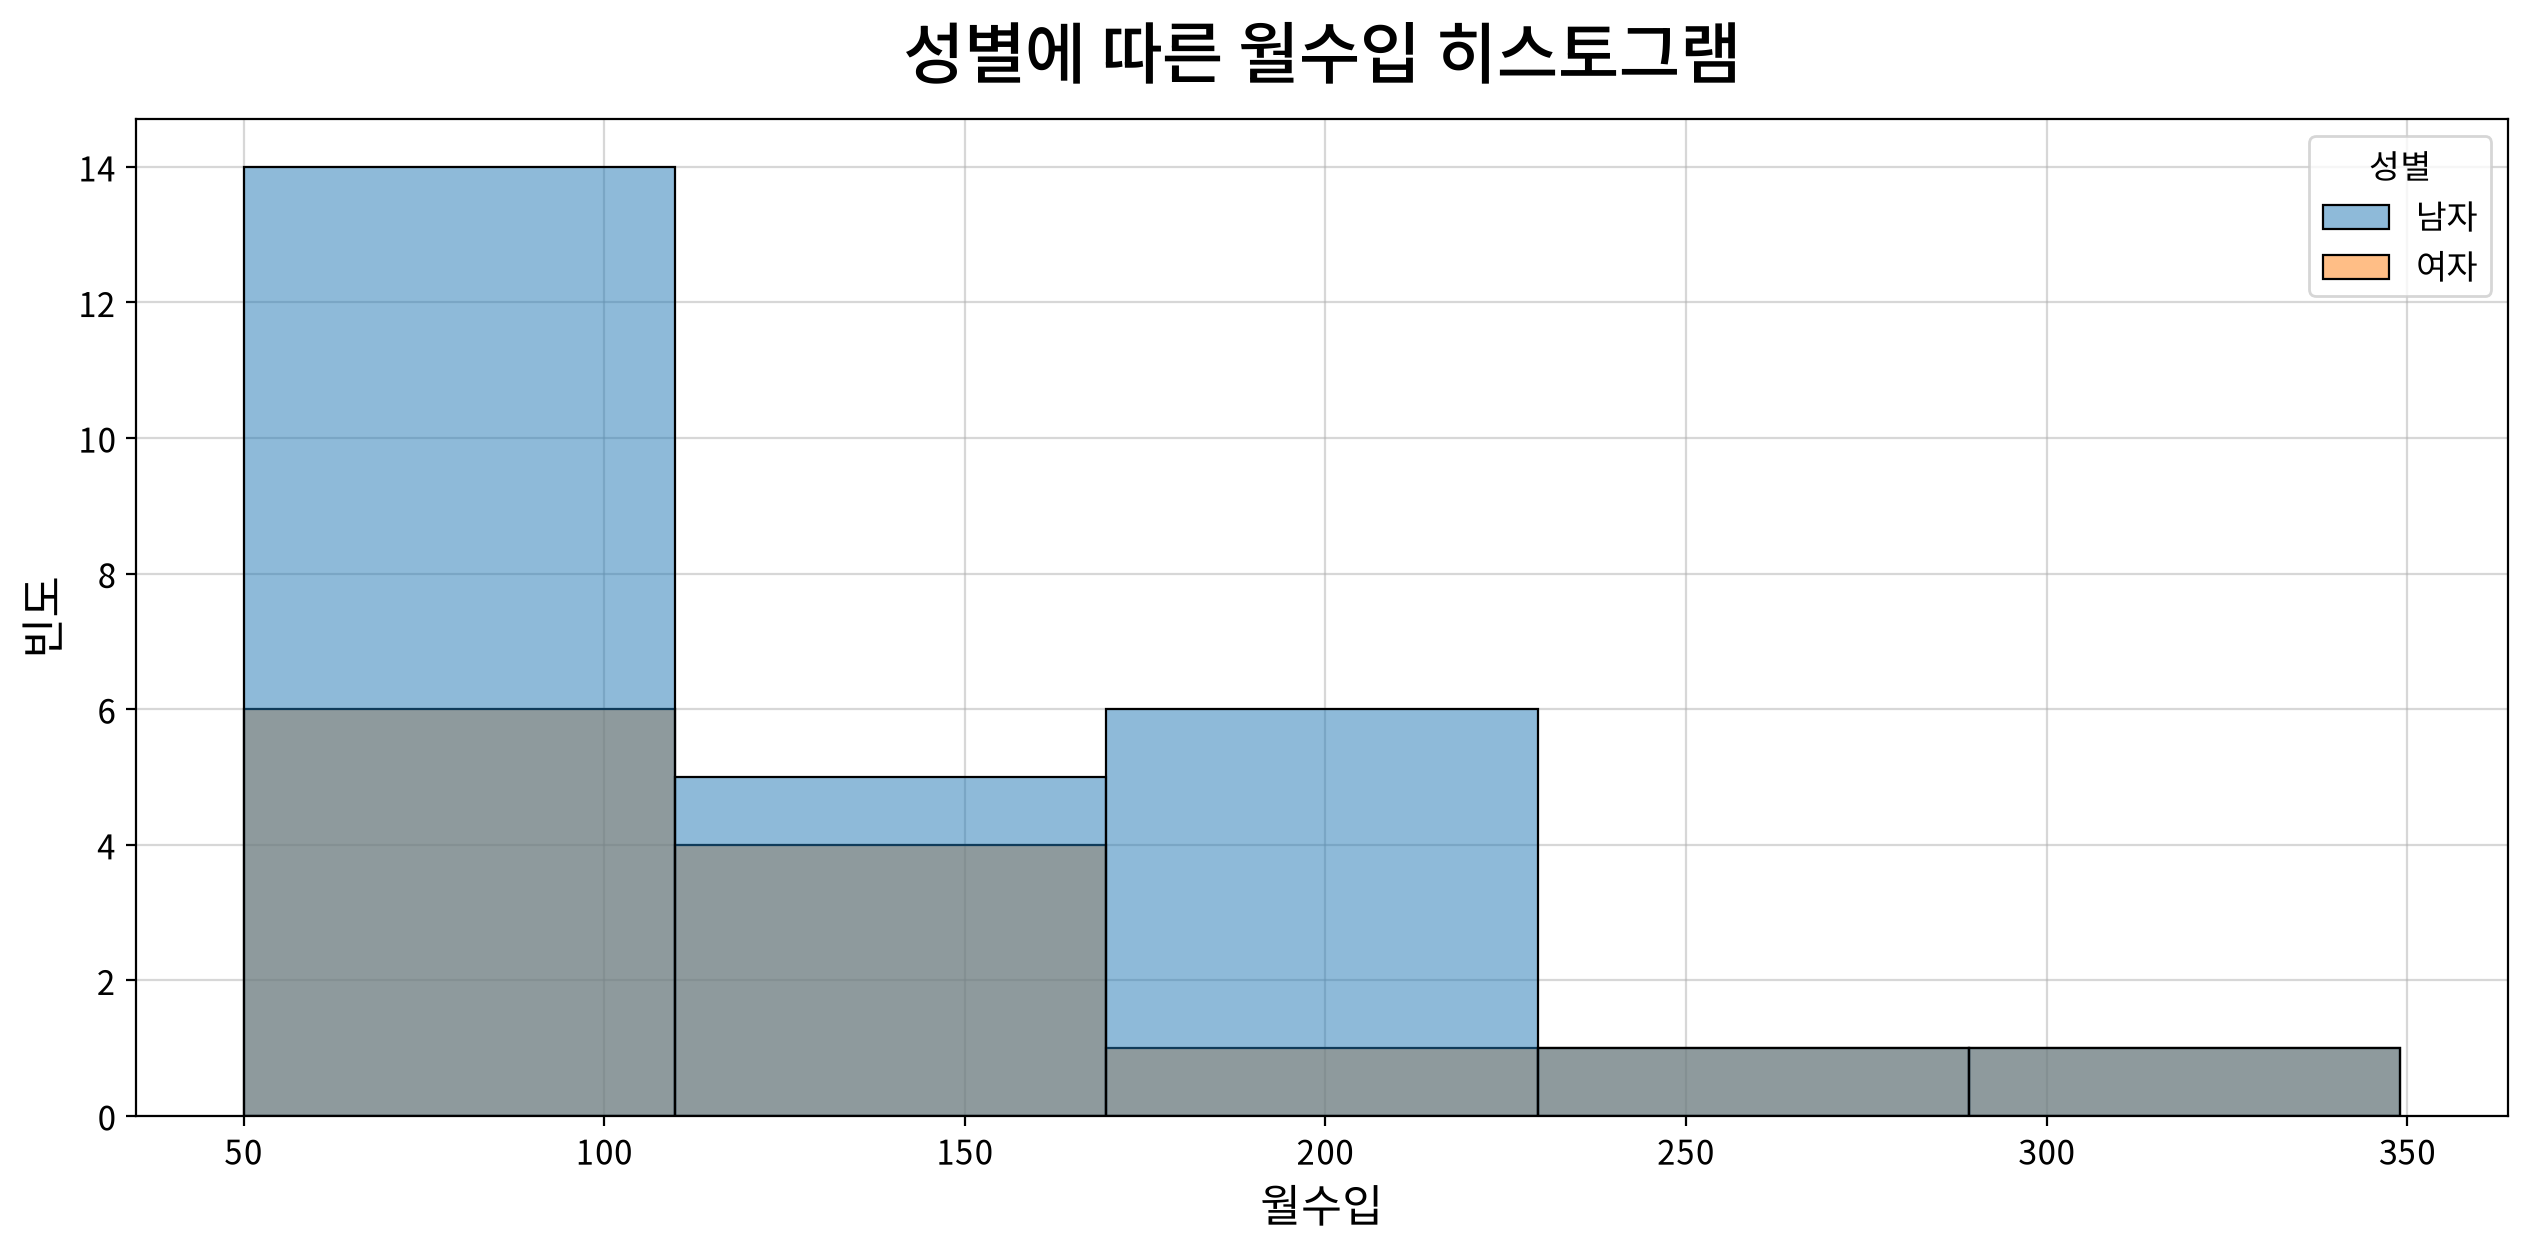

In [7]:
fig, ax = my_plot.init(title='성별에 따른 월수입 히스토그램', 
                       xlabel='월수입', ylabel='빈도')

sb.histplot(data=origin, x='월수입', hue='성별', bins=bins,
            edgecolor="#000000", linewidth=0.8)

my_plot.show()

## #05. 모듈화 기능 확인

### 1. 히스토그램 모듈 사용하기

- 모듈 코드의 변경사항을 jupyter에 인식시키기 위해 jupyter를 재시작 후 기존 코드를 모두 재실행 해야 한다.

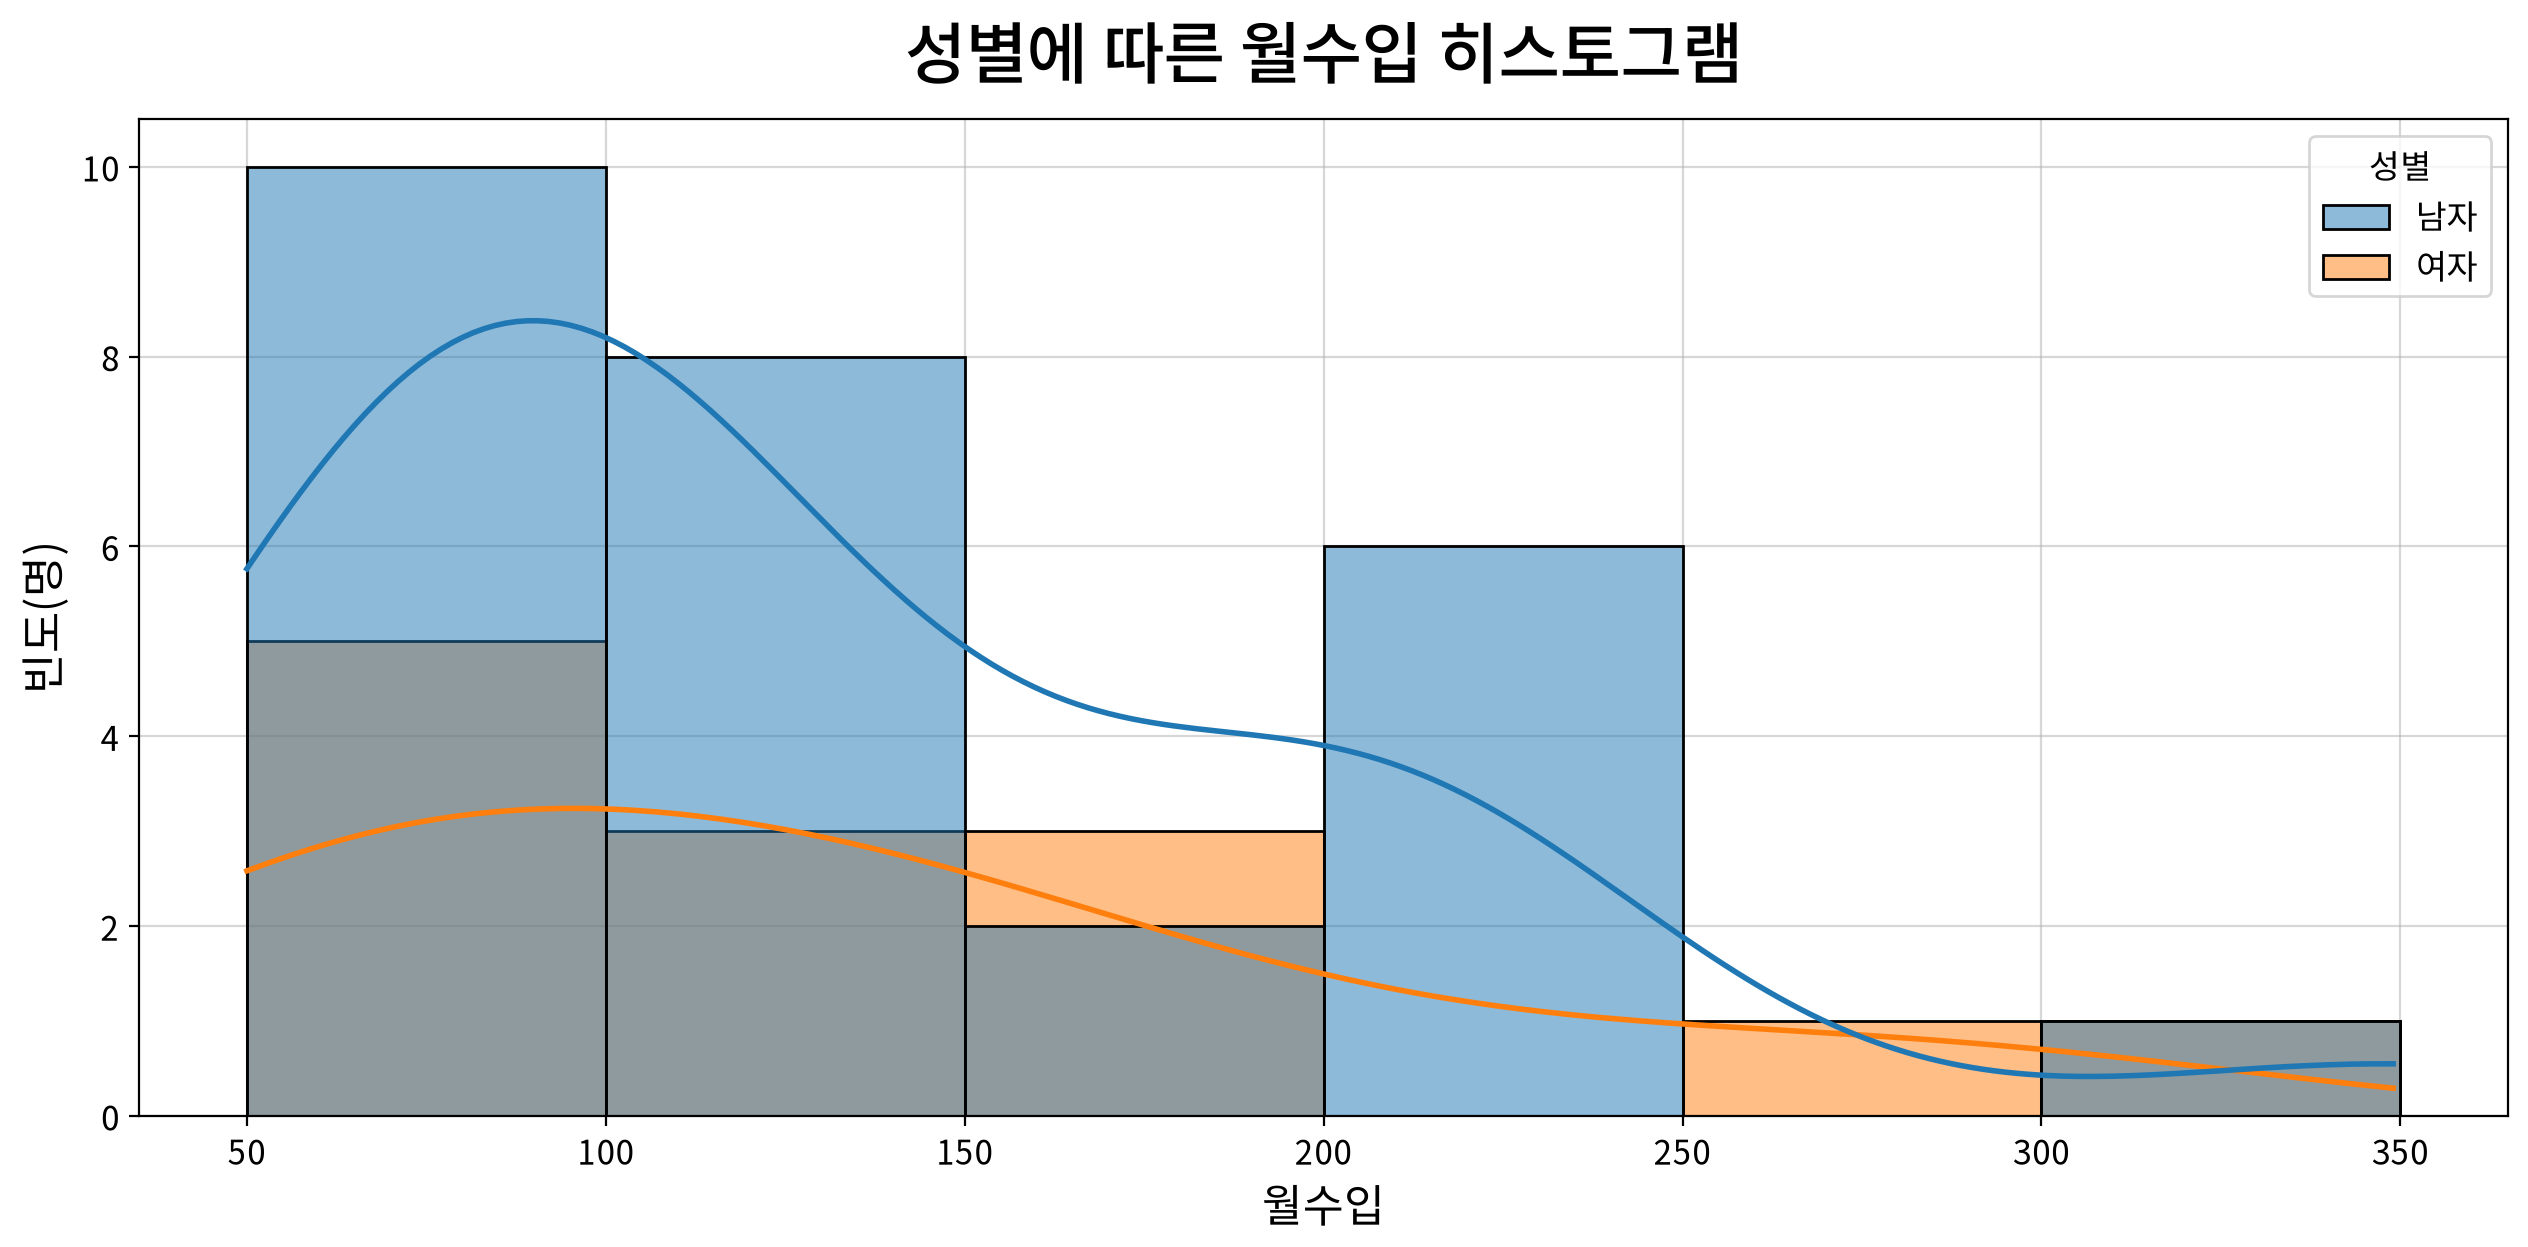

In [8]:
my_plot.histplot(data=origin, x='월수입', hue='성별', 
                 bins=[50, 100, 150, 200, 250, 300, 350], kde=True,
                 title='성별에 따른 월수입 히스토그램', 
                 xlabel='월수입', ylabel='빈도(명)')